In [ ]:
import pandas as pd

In [ ]:
df = pd.read_pickle('df_clusters.pkl')

In [ ]:
# prompt: delete every column with cluster in name

# Select columns to keep
cols_to_keep = [col for col in df.columns if 'cluster' not in col.lower()]

# Create a new DataFrame with only the desired columns
df = df[cols_to_keep]

# Print the columns to verify
df.columns

Index(['adult', 'based on novel or book', 'sequel', 'superhero',
       'based on comic', 'based on a true story', 'marvel',
       'director_Mel_Gibson', 'director_Sam_Taylor_Johnson',
       'director_Rodney_Rothman',
       ...
       'genre_Horror', 'genre_Western', 'genre_Science_Fiction', 'genre_Music',
       'genre_Romance', 'genre_Adventure', 'genre_Animation', 'runtime_log',
       'target_value', 'label'],
      dtype='object', length=228)

In [ ]:
# prompt: drop column target_value

df = df.drop('target_value', axis=1)
df.columns

Index(['adult', 'based on novel or book', 'sequel', 'superhero',
       'based on comic', 'based on a true story', 'marvel',
       'director_Mel_Gibson', 'director_Sam_Taylor_Johnson',
       'director_Rodney_Rothman',
       ...
       'genre_Fantasy', 'genre_Horror', 'genre_Western',
       'genre_Science_Fiction', 'genre_Music', 'genre_Romance',
       'genre_Adventure', 'genre_Animation', 'runtime_log', 'label'],
      dtype='object', length=227)

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1868, 226)
Shape of X_test: (623, 226)
Shape of y_train: (1868,)
Shape of y_test: (623,)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))
print(class_weights)

{np.int64(0): np.float64(1.2453333333333334), np.int64(1): np.float64(1.3536231884057972), np.int64(2): np.float64(0.8399280575539568), np.int64(3): np.float64(0.7888513513513513)}


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate a RandomForestClassifier object
rf_classifier = RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from scipy.stats import randint, uniform

# Define the hyperparameter distribution
param_distributions = {
    'n_estimators': randint(100, 500),
    'max_features': ['sqrt', 'log2'],
    'max_depth': randint(10, 50),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20),
    'bootstrap': [True, False]
}

# Instantiate KFold for cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Instantiate RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf_classifier,
    param_distributions=param_distributions,
    n_iter=100,  # Number of iterations for random search
    cv=cv,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1  # Use all available cores
)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=RandomForestClassifier(random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78d53abe2050>,
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78d53975a990>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78d53975a210>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78d539cfb010>},
                   random_state=42, scoring='f1_macro')

In [ ]:
from sklearn.ensemble import RandomForestClassifier

best_params = random_search.best_params_

# Initialize a new RandomForestClassifier model with best parameters and class weights
best_rf_model = RandomForestClassifier(random_state=42, class_weight=class_weights, **best_params)

# Train the model
best_rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight={np.int64(0): np.float64(1.2453333333333334),
                                     np.int64(1): np.float64(1.3536231884057972),
                                     np.int64(2): np.float64(0.8399280575539568),
                                     np.int64(3): np.float64(0.7888513513513513)},
                       max_depth=23, min_samples_split=6, n_estimators=317,
                       random_state=42)

Accuracy: 0.3178

Classification Report:
              precision    recall  f1-score   support

           0       0.17      0.15      0.16       117
           1       0.26      0.22      0.24       120
           2       0.38      0.49      0.43       174
           3       0.36      0.33      0.34       212

    accuracy                           0.32       623
   macro avg       0.29      0.30      0.29       623
weighted avg       0.31      0.32      0.31       623


Macro Average Precision: 0.2917
Macro Average Recall: 0.2961
Macro Average F1-score: 0.2914


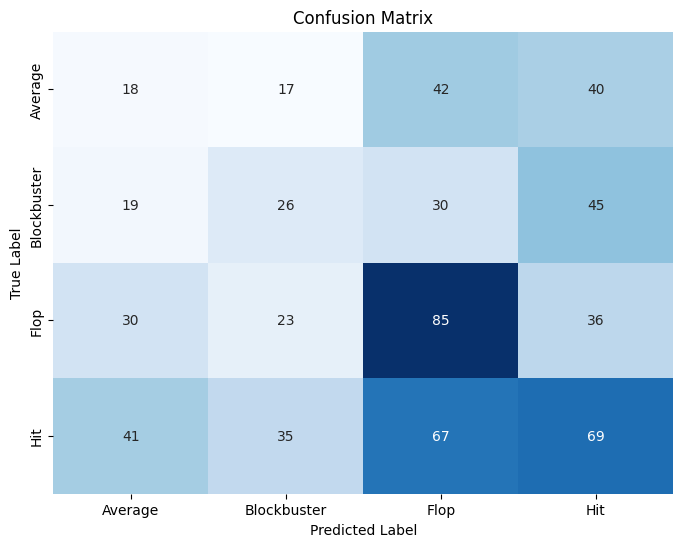

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred = best_rf_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Generate classification report
report = classification_report(y_test, y_pred, output_dict=True)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Extract macro average metrics
macro_precision = report['macro avg']['precision']
macro_recall = report['macro avg']['recall']
macro_f1_score = report['macro avg']['f1-score']

print(f"\nMacro Average Precision: {macro_precision:.4f}")
print(f"Macro Average Recall: {macro_recall:.4f}")
print(f"Macro Average F1-score: {macro_f1_score:.4f}")


# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get the original class labels
original_labels = label_encoder.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=original_labels, yticklabels=original_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()